In [1]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
from astropy.io import fits

# Define path to the data
path = '/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/vx/100G/simulation_vx_100G_33570s_47970s.nc'

# Load in the data from the netCDF file
data = nc.Dataset(path)

# Define the variables to extract from the dataset
v1, v2, v3 = data.variables['v1'][:].data, data.variables['v2'][:].data, data.variables['v3'][:].data

# Pack into a vector
v = np.array([v1, v2, v3])

In [2]:
def curl(v, k):
    
    ''' 
    Purpose
    -------
    Compute the curl of a 3D vector field v = (v1, v2, v3) using finite differences.
    
    Parameters
    ----------
    v : numpy.ndarray
        A 3D vector field represented as a 4D array with shape (3, nx, ny, nz), where the first dimension corresponds to the vector components (v1, v2, v3).
    k : int
        The index along the second dimension to compute the curl for.

    Returns
    -------
    numpy.ndarray
        The curl of the vector field, represented as a 2D array with shape (nx, ny).
        
    Author(s)
    ---------
    Julio Morales, June 24th, 2026
    '''
    
    # Unpack the vector field components
    vx, vy, vz = v[0, :, k, :, :], v[1, :, k, :, :], v[2, :, k, :, :]
    
    # Define empty array for vorticity
    vorticity = np.zeros_like(vx)
    
    # Loop through each time
    for t in range(vx.shape[0]):
        
        # Compute the curl components
        curl_z = np.gradient(vy[t], axis=0) - np.gradient(vx[t], axis=1)
        
        # Store the curl components in the vorticity array
        vorticity[t] = curl_z
    
    return vorticity

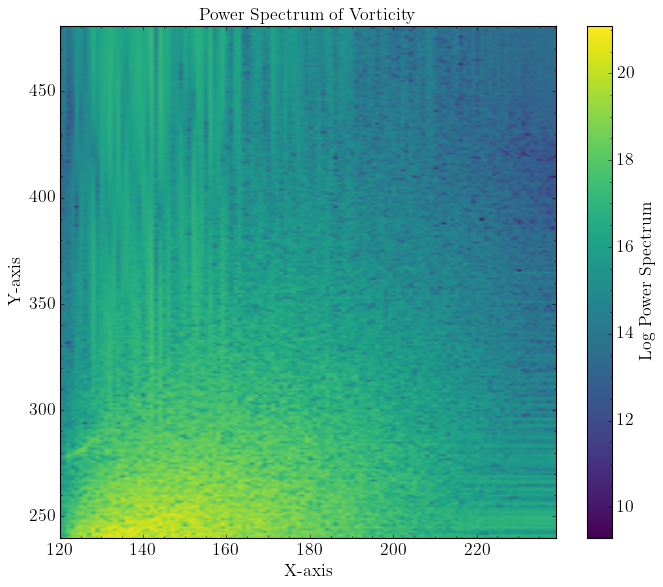

In [4]:
# Compute the vorticity of the vector field
vorticity = curl(v, 0)  # You can choose appropriate indices for i and j based on your data

# Take the Fourier transform of the vorticity
fft = np.fft.fftshift(np.fft.fftn(vorticity))

# Find the power spectrum of the vorticity
power_spectrum = np.abs(fft)**2

# Plot the power spectrum of the vorticity
plt.figure(figsize=(10, 8))
plt.imshow(np.log10(power_spectrum[:, :, 240//2]), cmap='viridis', origin='lower', aspect ='auto')
plt.colorbar(label='Log Power Spectrum')
plt.title('Power Spectrum of Vorticity')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.ylim(240, 481)
plt.xlim(120, 239)
plt.show()

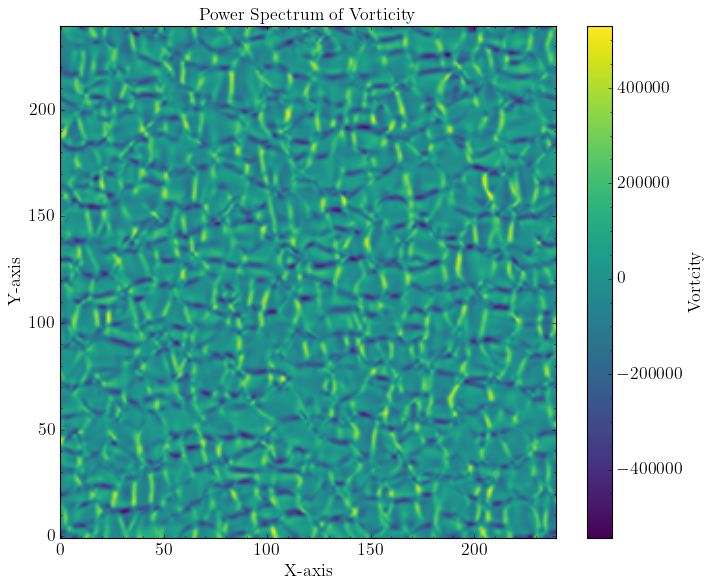

In [6]:

# Plot the power spectrum of the vorticity
plt.figure(figsize=(10, 8))
plt.imshow(vorticity[0, :, :], cmap='viridis', origin='lower', aspect ='auto')
plt.colorbar(label='Vortcity')
plt.title('Power Spectrum of Vorticity')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

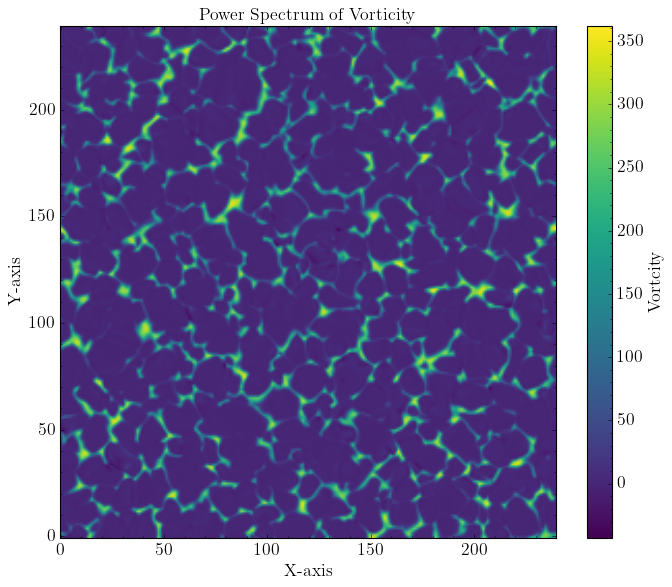

In [10]:
bx = data.variables['bb3'][:].data
# Plot the power spectrum of the vorticity
plt.figure(figsize=(10, 8))
plt.imshow(bx[0, 0, :, :], cmap='viridis', origin='lower', aspect ='auto')
plt.colorbar(label='Vortcity')
plt.title('Power Spectrum of Vorticity')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()